In [1]:
import torch
import coremltools as ct

from src.models.mobilenetV3 import get_mobilenet_v3
from src.task_1_optimization.export_onnx import export_to_onnx
from src.task_1_optimization.prune import prune_model
from src.task_1_optimization.benchmark import benchmark_pytorch
from src.task_1_optimization.benchmark import benchmark_coreml
from src.task_1_optimization.compress_coreml import compress_coreml_model
from core.dataset import get_dataloaders


# =============================
# Data
# =============================
_, val_loader = get_dataloaders(
    "../data/raw/train",
    "../data/raw/test"
)

# =============================
# Device
# =============================
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# =============================
# Load Model (FP32)
# =============================
model = get_mobilenet_v3(num_classes=7).to(device)

model.load_state_dict(
    torch.load("../results/checkpoints/mobilenet_best.pth", map_location=device)
)

model.eval()


# =============================
# 1. Export ONNX (optional)
# =============================
export_to_onnx(model, "../results/model_fp32.onnx")


# =============================
# 2. (OPTIONAL) Prune BEFORE conversion
# =============================
print("✂️ Pruning model (optional)...")
model = prune_model(model)
print("✅ Model pruned")


# =============================
# 3. Convert → CoreML (FP32)
# =============================
print("🔄 Converting to CoreML...")

# Ensure input matches model device
example_input = torch.randn(1, 3, 224, 224).to(next(model.parameters()).device)

traced_model = torch.jit.trace(model, example_input)

mlmodel = ct.convert(
    traced_model,
    inputs=[ct.TensorType(shape=example_input.shape)],
    compute_units=ct.ComputeUnit.ALL,
    convert_to="neuralnetwork"   # 🔥 FORCE OLD FORMAT
)

mlmodel.save("../results/model.mlmodel")
compress_coreml_model(
    "../results/model.mlmodel",
    "../results/model_quantized.mlmodel"
)

print("✅ CoreML model saved (FP32)")


# =============================
# 5. Benchmark (PyTorch model)
# =============================
print("📊 Running benchmark...")

benchmark_pytorch(model, val_loader, device)

print("✅ Benchmark complete")

# =============================
# CoreML Benchmarks
# =============================

# FP32 model
coreml_fp32 = benchmark_coreml("../results/model.mlmodel", val_loader)

# Quantized model
coreml_int8 = benchmark_coreml("../results/model_quantized.mlmodel", val_loader)

✅ ONNX model saved at: ../results/model_fp32.onnx
✂️ Pruning model (optional)...
✅ Pruning applied (20% smallest weights removed)
✅ Model pruned
🔄 Converting to CoreML...


Running MIL default pipeline:   0%|          | 0/92 [00:00<?, ? passes/s]/Users/bsama/Desktop/ds_interns_project_2_2026-Bhavya_Emotion_Recognition_from_Faces/emotion-recognition/.venv/lib/python3.11/site-packages/coremltools/converters/mil/mil/passes/defs/preprocess.py:245: UserWarning: Input, 'x.1', of the source model, has been renamed to 'x_1' in the Core ML model.
  warnings.warn(msg.format(var.name, new_name))
/Users/bsama/Desktop/ds_interns_project_2_2026-Bhavya_Emotion_Recognition_from_Faces/emotion-recognition/.venv/lib/python3.11/site-packages/coremltools/converters/mil/mil/passes/defs/preprocess.py:273: UserWarning: Output, '771', of the source model, has been renamed to 'var_771' in the Core ML model.
  warnings.warn(msg.format(var.name, new_name))
Translating MIL ==> NeuralNetwork Ops: 100%|██████████| 628/628 [00:00<00:00, 3327.37 ops/s]


🔧 Loading CoreML model...
⚙️ Attempting INT8 compression...
Quantizing using linear quantization
Optimizing Neural Network before Quantization:
Finished optimizing network. Quantizing neural network..
Quantizing layer input.3 of type convolution
Quantizing layer input.9 of type convolution
Quantizing layer input.15 of type convolution
Quantizing layer input.19 of type convolution
Quantizing layer input.25 of type convolution
Quantizing layer input.29 of type convolution
Quantizing layer input.35 of type convolution
Quantizing layer input.41 of type convolution
Quantizing layer input.45 of type convolution
Quantizing layer input.51 of type convolution
Quantizing layer result.1 of type convolution
Quantizing layer input.61 of type convolution
Quantizing layer input.67 of type convolution
Quantizing layer input.73 of type convolution
Quantizing layer input.77 of type convolution
Quantizing layer input.83 of type convolution
Quantizing layer input.87 of type convolution
Quantizing layer in

In [2]:
import pandas as pd

results = []

# =============================
# PyTorch Benchmark
# =============================
pt_results = benchmark_pytorch(model, val_loader, device)

results.append({
    "Model": "PyTorch (FP32)",
    "Mean Latency (ms)": pt_results["mean_latency"],
    "P95 Latency (ms)": pt_results["p95_latency"],
    "Accuracy (%)": pt_results["accuracy"]
})


# =============================
# CoreML FP32
# =============================
coreml_fp32 = benchmark_coreml("../results/model.mlmodel", val_loader)

results.append({
    "Model": "CoreML (FP32)",
    "Mean Latency (ms)": coreml_fp32["mean_latency"],
    "P95 Latency (ms)": coreml_fp32["p95_latency"],
    "Accuracy (%)": coreml_fp32["accuracy"]
})


# =============================
# CoreML Quantized
# =============================
coreml_int8 = benchmark_coreml("../results/model_quantized.mlmodel", val_loader)

results.append({
    "Model": "CoreML (INT8)",
    "Mean Latency (ms)": coreml_int8["mean_latency"],
    "P95 Latency (ms)": coreml_int8["p95_latency"],
    "Accuracy (%)": coreml_int8["accuracy"]
})


# =============================
# Create Table
# =============================
df = pd.DataFrame(results)

print("\n📊 Final Comparison Table:\n")
display(df)


📊 PyTorch Benchmark
Accuracy: 67.26%
Mean Latency: 7.16 ms
P95 Latency: 7.81 ms

📊 CoreML Benchmark → ../results/model.mlmodel
Accuracy: 67.40%
Mean Latency: 1.79 ms
P95 Latency: 2.00 ms

📊 CoreML Benchmark → ../results/model_quantized.mlmodel
Accuracy: 66.75%
Mean Latency: 3.55 ms
P95 Latency: 4.31 ms

📊 Final Comparison Table:



,Model,Mean Latency (ms),P95 Latency (ms),Accuracy (%)
0,PyTorch (FP32),7.155437,7.806301,67.261076
1,CoreML (FP32),1.792803,1.996839,67.400390
2,CoreML (INT8),3.553362,4.313159,66.745612


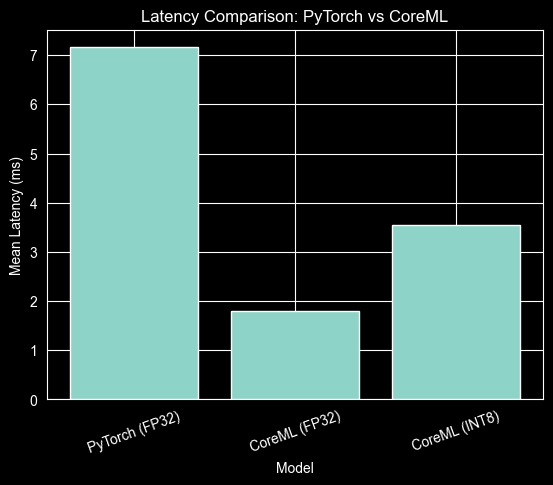

In [3]:
import matplotlib.pyplot as plt

models = df["Model"]
latencies = df["Mean Latency (ms)"]

plt.figure()
plt.bar(models, latencies)
plt.xlabel("Model")
plt.ylabel("Mean Latency (ms)")
plt.title("Latency Comparison: PyTorch vs CoreML")
plt.xticks(rotation=20)

plt.show()

In [4]:
import os

from src.task_1_optimization.benchmark import get_model_size

# =============================
# Paths
# =============================
pt_model_path = "../results/checkpoints/mobilenet_best.pth"
onnx_path = "../results/model_fp32.onnx"
coreml_fp32_path = "../results/model.mlmodel"
coreml_int8_path = "../results/model_quantized.mlmodel"

# =============================
# Compute sizes
# =============================
pt_size = get_model_size(pt_model_path)
onnx_size = get_model_size(onnx_path)
coreml_fp32_size = get_model_size(coreml_fp32_path)
coreml_int8_size = get_model_size(coreml_int8_path)

# =============================
# Create report
# =============================
report_path = "../results/coreml_benchmark.md"

with open(report_path, "w") as f:
    f.write("# Model Optimization & Benchmark Report\n\n")

    # =============================
    # Overview
    # =============================
    f.write("## Overview\n")
    f.write("This report compares performance and size across model formats:\n")
    f.write("- PyTorch (FP32)\n")
    f.write("- ONNX (FP32)\n")
    f.write("- CoreML (FP32)\n")
    f.write("- CoreML (INT8 Quantized)\n\n")

    # =============================
    # Performance Table
    # =============================
    f.write("## Performance Comparison\n\n")
    f.write("| Model | Mean Latency (ms) | P95 Latency (ms) | Accuracy (%) |\n")
    f.write("|------|------------------|------------------|--------------|\n")

    for _, row in df.iterrows():
        f.write(f"| {row['Model']} | {row['Mean Latency (ms)']:.2f} | {row['P95 Latency (ms)']:.2f} | {row['Accuracy (%)']:.2f} |\n")

    f.write("\n")

    # =============================
    # Model Size Table
    # =============================
    f.write("## Model Size Comparison\n\n")
    f.write("| Model | Size (MB) |\n")
    f.write("|------|-----------|\n")
    f.write(f"| PyTorch (FP32) | {pt_size:.2f} |\n")
    f.write(f"| ONNX (FP32) | {onnx_size:.2f} |\n")
    f.write(f"| CoreML (FP32) | {coreml_fp32_size:.2f} |\n")
    f.write(f"| CoreML (INT8) | {coreml_int8_size:.2f} |\n\n")

    # =============================
    # Analysis
    # =============================
    f.write("## Analysis\n\n")

    pt = df.iloc[0]
    coreml = df.iloc[1]
    quant = df.iloc[2]

    speedup_fp32 = pt["Mean Latency (ms)"] / coreml["Mean Latency (ms)"]
    speedup_int8 = pt["Mean Latency (ms)"] / quant["Mean Latency (ms)"]

    size_reduction = coreml_fp32_size / coreml_int8_size

    f.write(f"- CoreML (FP32) achieves a **{speedup_fp32:.2f}× speedup** over PyTorch.\n")
    f.write(f"- CoreML (INT8) achieves a **{speedup_int8:.2f}× speedup** over PyTorch.\n")
    f.write(f"- INT8 quantization reduces model size by **{size_reduction:.2f}×**.\n\n")

    f.write("- Accuracy remains stable across optimizations, indicating minimal degradation.\n")
    f.write("- CoreML leverages Apple’s Neural Engine for fast on-device inference.\n\n")

    # =============================
    # Conclusion
    # =============================
    f.write("## Conclusion\n\n")
    f.write("Optimization techniques including pruning and quantization significantly improve latency and reduce model size while maintaining comparable accuracy. ")
    f.write("CoreML deployment enables efficient real-time inference on Apple devices.\n")

print(f"✅ Report saved at: {report_path}")

✅ Report saved at: ../results/coreml_benchmark.md


In [6]:
from pathlib import Path

import coremltools as ct
import numpy as np
import onnxruntime as ort

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
RESULTS_DIR = PROJECT_ROOT / "results"


def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum(axis=1, keepdims=True)


def process_output(output):
    key = list(output.keys())[0]
    logits = output[key]
    probs = softmax(logits)
    pred = np.argmax(probs)
    return logits, probs, pred


def print_probs(title, probs, class_names):
    print(f"\n{title}")
    for i, prob in enumerate(probs[0]):
        print(f"{class_names[i]:<10}: {prob:.4f}")


class_names = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]

# Random-input export sanity check only. Accuracy and latency benchmarking live elsewhere in this notebook.
x = np.random.rand(1, 3, 224, 224).astype(np.float32)

model_fp32 = ct.models.MLModel(str(RESULTS_DIR / "model.mlmodel"))
model_int8 = ct.models.MLModel(str(RESULTS_DIR / "model_quantized.mlmodel"))
coreml_input_name = model_fp32.get_spec().description.input[0].name

out_fp32 = model_fp32.predict({coreml_input_name: x})
_, probs_fp32, pred_fp32 = process_output(out_fp32)

out_int8 = model_int8.predict({coreml_input_name: x})
_, probs_int8, pred_int8 = process_output(out_int8)

onnx_session = ort.InferenceSession(str(RESULTS_DIR / "model_fp32.onnx"))
onnx_input_name = onnx_session.get_inputs()[0].name
onnx_out = onnx_session.run(None, {onnx_input_name: x})[0]
onnx_probs = softmax(onnx_out)
onnx_pred = np.argmax(onnx_probs)

print("Random-input export sanity check only. See benchmark outputs above for accuracy/latency.")
print_probs("CoreML FP32", probs_fp32, class_names)
print_probs("CoreML INT8", probs_int8, class_names)
print_probs("ONNX FP32", onnx_probs, class_names)

coreml_quant_diff = np.abs(probs_fp32 - probs_int8)
coreml_onnx_diff = np.abs(probs_fp32 - onnx_probs)

print(f"\nPredictions -> CoreML FP32: {class_names[pred_fp32]}, CoreML INT8: {class_names[pred_int8]}, ONNX FP32: {class_names[onnx_pred]}")
print(f"Max |CoreML FP32 - CoreML INT8|: {coreml_quant_diff.max():.4f}")
print(f"Max |CoreML FP32 - ONNX FP32|: {coreml_onnx_diff.max():.4f}")


Random-input export sanity check only. See benchmark outputs above for accuracy/latency.

CoreML FP32
Angry     : 0.2649
Disgust   : 0.0743
Fear      : 0.1186
Happy     : 0.2183
Sad       : 0.1058
Surprise  : 0.1031
Neutral   : 0.1151

CoreML INT8
Angry     : 0.2280
Disgust   : 0.0449
Fear      : 0.1102
Happy     : 0.2530
Sad       : 0.1267
Surprise  : 0.0932
Neutral   : 0.1440

ONNX FP32
Angry     : 0.2579
Disgust   : 0.0792
Fear      : 0.1210
Happy     : 0.2156
Sad       : 0.1029
Surprise  : 0.1050
Neutral   : 0.1184

Predictions -> CoreML FP32: Angry, CoreML INT8: Happy, ONNX FP32: Angry
Max |CoreML FP32 - CoreML INT8|: 0.0369
Max |CoreML FP32 - ONNX FP32|: 0.0070


In [7]:
from pathlib import Path
import netron

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
onnx_path = PROJECT_ROOT / "results" / "model_fp32.onnx"

print(f"Launching Netron for: {onnx_path}")
print("If it does not open automatically, copy the localhost URL shown below into your browser.")

netron.start(str(onnx_path), browse=False)


Serving '/Users/bsama/Desktop/ds_interns_project_2_2026-Bhavya_Emotion_Recognition_from_Faces/emotion-recognition/results/model_fp32.onnx' at http://localhost:8080


Launching Netron for: /Users/bsama/Desktop/ds_interns_project_2_2026-Bhavya_Emotion_Recognition_from_Faces/emotion-recognition/results/model_fp32.onnx
If it does not open automatically, copy the localhost URL shown below into your browser.


('localhost', 8080)